In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sys import path
path.append('../../wavelet/')
import wavelet_funcs as wf

import ssqueezepy as sq

## White noise - CWT coefficients are flat for L2 norm, and grow as sqrt(f) for L1 norm

In [3]:
n = 50_000
dt = 0.01 # s
fs = 1/dt

x = np.random.randn(n)
t = np.arange(n)*dt

## L1 norm, default

In [6]:
wav = sq.Wavelet(('morlet', {'mu': 13.4}))
W, scales = sq.cwt(x, wavelet=wav, fs=fs, l1_norm=True)
freqs = sq.experimental.scale_to_freq(scales, wav, n, fs)

(<Figure size 1000x400 with 1 Axes>,
 <Axes: >,
 <matplotlib.collections.QuadMesh at 0x1ae1061e710>)

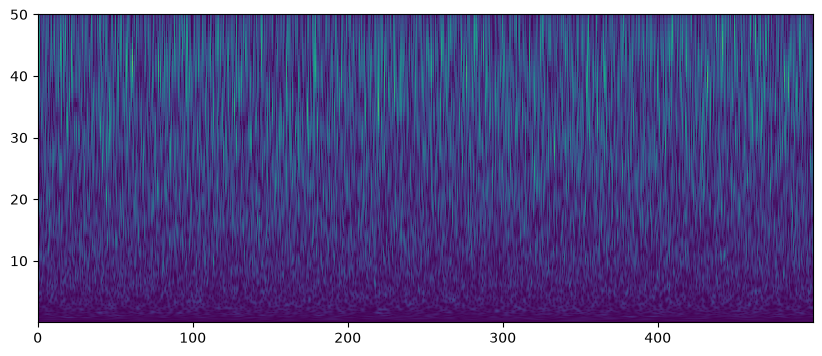

In [10]:
wf.plot_cwt(abs(W), freqs, t);

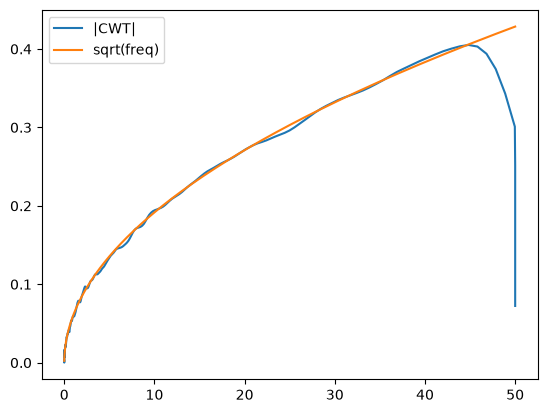

In [12]:
y = abs(W).mean(axis=1)

plt.plot(freqs, y, label='|CWT|')
plt.plot(freqs, np.sqrt(freqs)/16.5, label='sqrt(freq)')
plt.legend()
# plt.xscale('log')

## L2 norm

In [14]:
W, scales = sq.cwt(x, wavelet=wav, fs=fs, l1_norm=False)
freqs = sq.experimental.scale_to_freq(scales, wav, n, fs)

(<Figure size 1000x400 with 1 Axes>,
 <Axes: >,
 <matplotlib.collections.QuadMesh at 0x1ae140891d0>)

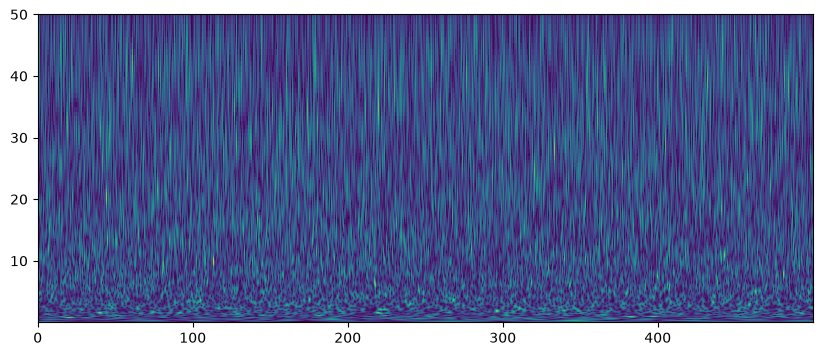

In [16]:
wf.plot_cwt(abs(W), freqs, t)

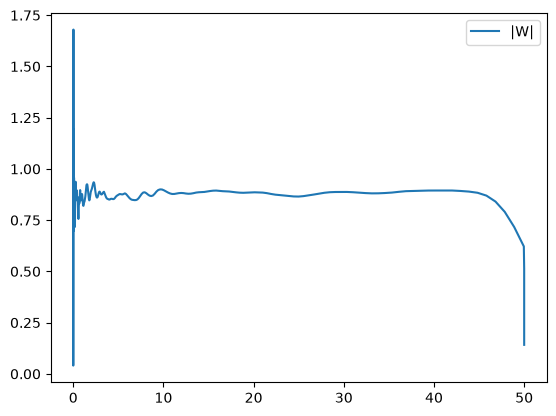

In [18]:
y = abs(W).mean(axis=1)

plt.plot(freqs, y, label='|W|')
# plt.plot(freqs, x.std(), label='sqrt(freq)')
# plt.axhline(x.std(), ls='--', label='Signal STD', color='k')
plt.legend()
# plt.xscale('log')

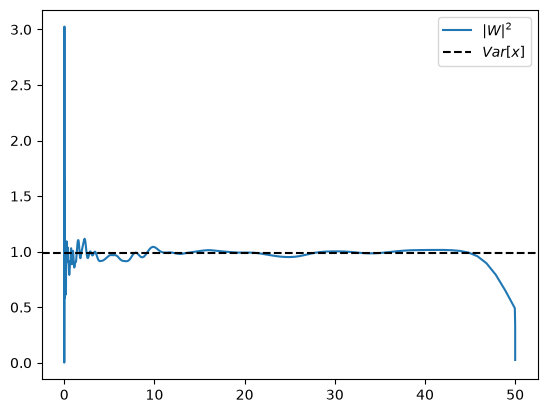

In [20]:
y = (abs(W)**2).mean(axis=1)

plt.plot(freqs, y, label='$|W|^2$')
# plt.plot(freqs, x.std(), label='sqrt(freq)')
plt.axhline(x.std()**2, ls='--', label='$Var[x]$', color='k')
plt.legend()
# plt.xscale('log')

## Wavelet power of white noise should equal the noise's variance, for L2 normalization. It looks to be so for ssqueezepy's cwt with l1_norm=False

## - Coefficients at low frequency are more noisy, naturally, because the signal duration is fixed for all frequencies, but wavelet width (timespan) is larger for low frequencies, hence there's less information about low frequencies than about high.

## - Coefficients drop for high frequency (approaching Nyquist). MATLAB implementation makes maximal frequency lower than Nyquist.

## Check that the mean |W|^2 changes as Var[x]

In [292]:
sigmas = np.array([0.2, 0.5, 1, 2, 4, 8, 16, 32])
n = 50_000
signals = np.random.randn(sigmas.size, n) * sigmas.reshape((1, sigmas.size)).T

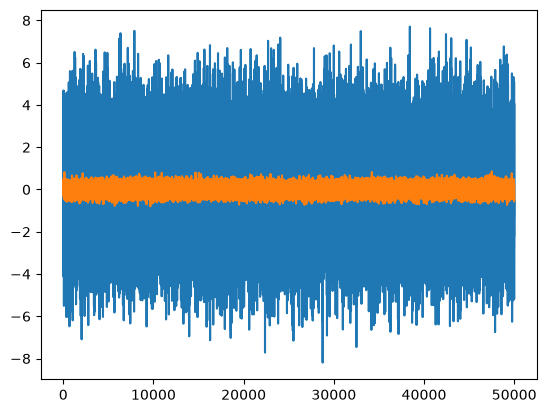

In [294]:
plt.plot(signals[3])
plt.plot(signals[0])

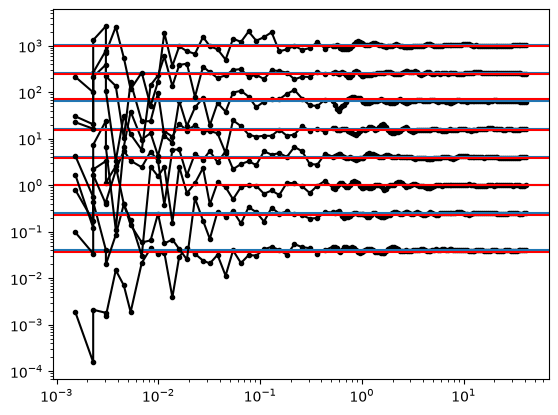

In [296]:
frac_drop = 0.15 # at the end of the range

plt.figure()

results = []

for sigma, x in zip(sigmas, signals):
    W, scales = sq.cwt(x, wavelet=wav, fs=fs, l1_norm=False, nv=16)
    freqs = sq.experimental.scale_to_freq(scales, wav, n, fs)
    
    sele = (freqs<max(freqs)*(1-frac_drop))
    
    freqs_sel = freqs[sele]
    W_sele = np.mean(abs(W[sele])**2, axis=1)
    
    plt.loglog(freqs_sel, W_sele, marker='.', color='k')
    plt.axhline(sigma**2)
    plt.axhline(W_sele.mean(), color='r')
    
    results.append([W_sele.mean(), sigma**2])

## I neglet underestimation at low frequencies: only small fraction of dots is at small frequencies

In [298]:
results = np.array(results)

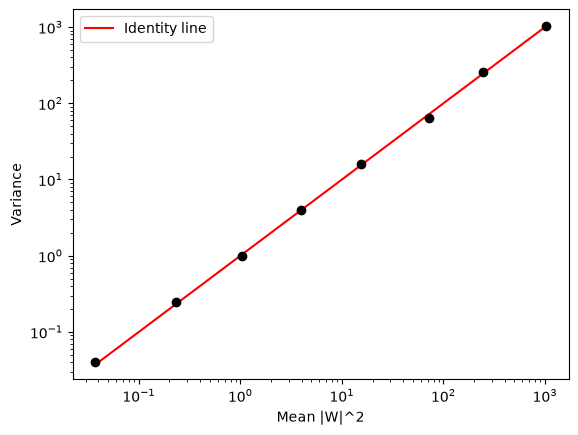

In [369]:
plt.plot(results.T[1], results.T[1], color='r', label='Identity line')
plt.loglog(results.T[0], results.T[1], marker='o', ls='', color='k')

plt.gca().set(xlabel='Mean |W|^2',
              ylabel='Variance'
             )
plt.legend()

# Mean wavelet power consistent with noise variance

----

## Something funny is going on with frequency spacing for nv higher than 16

In [320]:
x = signals[2]
W, scales = sq.cwt(x, wavelet=wav, fs=fs, l1_norm=False, nv=32) # default nv=32
freqs = sq.experimental.scale_to_freq(scales, wav, n, fs)
sele = (freqs<max(freqs)*(1-frac_drop))
freqs_sel = freqs[sele]
W_sele = np.mean(abs(W[sele])**2, axis=1)

Text(0.5, 1.0, 'Looks like frequency step varies\nfrom point to point at low freqs')

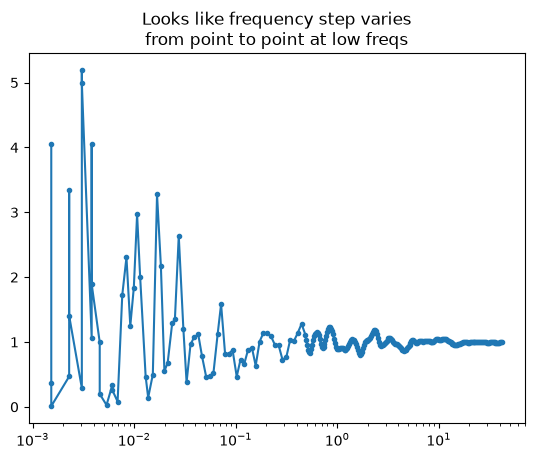

In [326]:
plt.semilogx(freqs_sel, W_sele, marker='.')
plt.title('Looks like frequency step varies\nfrom point to point at low freqs')

In [346]:
freq_step = abs(np.diff(freqs_sel))

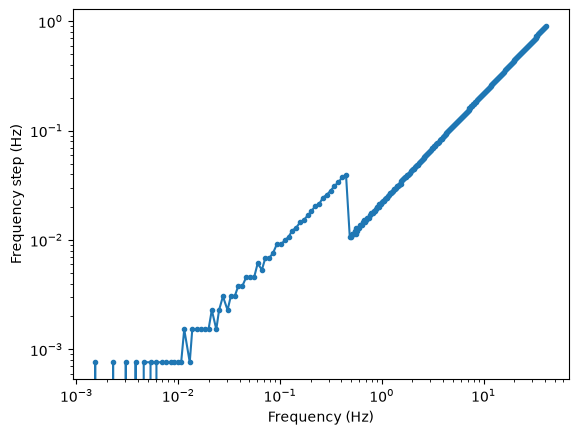

In [350]:
plt.loglog(freqs_sel[1:], freq_step, marker='.')
plt.gca().set(title='',
              xlabel='Frequency (Hz)',
              ylabel='Frequency step (Hz)'
             );

In [358]:
freq_step[-20:]

array([0.00076294, 0.00076294, 0.00076294, 0.00076294, 0.        ,
       0.00076294, 0.00076294, 0.        , 0.00076294, 0.        ,
       0.        , 0.00076294, 0.        , 0.        , 0.00076294,
       0.        , 0.        , 0.00076294, 0.        , 0.        ])

### Zeros in frequency step

In [365]:
freqs_sel[-10:]

array([0.0038147 , 0.00305176, 0.00305176, 0.00305176, 0.00228882,
       0.00228882, 0.00228882, 0.00152588, 0.00152588, 0.00152588])

### There are materials written by ssqueezepy's developer, possibly

- One solution, to set scales manually
- Another, to reduce nv